In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

import joblib

In [2]:
original_df=pd.read_csv("final_data_bin.csv")

In [3]:
df=original_df.drop("jobma_catcher_id", axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4466 entries, 0 to 4465
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   company_size             4466 non-null   object 
 1   is_premium               4466 non-null   int64  
 2   subscription_status      4466 non-null   int64  
 3   jobma_catcher_status     4466 non-null   int64  
 4   sub_users                4466 non-null   int64  
 5   wallet_amount            4466 non-null   float64
 6   is_unlimited             4466 non-null   int64  
 7   plan_type                4466 non-null   int64  
 8   subscription_sum         4466 non-null   float64
 9   subscription_count       4466 non-null   int64  
 10  invitations              4466 non-null   int64  
 11  pre_recorded_kit_counts  4466 non-null   int64  
 12  number_of_jobs_posted    4466 non-null   int64  
 13  pre_rec_interview_taken  4466 non-null   int64  
 14  days_since_login        

In [5]:
binary_columns = ['is_premium','subscription_status','jobma_catcher_status','is_unlimited','plan_type']

categorical_columns = ['company_size', 'days_since_login']
                   
numerical_columns= ['sub_users', 'wallet_amount', 'subscription_count', 'invitations',
                    'pre_recorded_kit_counts', 'number_of_jobs_posted','pre_rec_interview_taken']

ordinal_columns =['subscription_sum']

# Clean binary values , # Remove negatives and  clamp to 0
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)

def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_numerical(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce'))

def clean_ordinal(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce')).clip(lower=0)
    

# Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(lambda x: np.log1p(x), validate=False)),
                                  ])

numerical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_numerical, validate=False)),
                                     ('imputer', SimpleImputer(strategy='mean')),
                                    ])

preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns), 
                                               ('ord', ordinal_pipeline, ordinal_columns),
                                               ('num', numerical_pipeline, numerical_columns),
                                              ])

# Final pipeline
pipeline = Pipeline([('preprocessing', preprocessor),
                    ('scaler', StandardScaler())])

In [6]:
X = pipeline.fit_transform(df)
X_tensor = torch.tensor(X, dtype=torch.float32)
X_tensor.shape

torch.Size([4466, 32])

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        reconstructed = self.decoder(embeddings)
        return reconstructed, embeddings

In [8]:
input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 30
batch_size = 16

In [9]:
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(0, len(X_tensor), batch_size):
        x_batch = X_tensor[i:i + batch_size]

        optimizer.zero_grad()
        reconstructed, _ = model(x_batch)
        
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_tensor) / batch_size)
    loss_history.append(avg_loss)

    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 2/30, Loss: 0.7525
Epoch 4/30, Loss: 0.3099
Epoch 6/30, Loss: 0.1003
Epoch 8/30, Loss: 0.0375
Epoch 10/30, Loss: 0.0462
Epoch 12/30, Loss: 0.0340
Epoch 14/30, Loss: 0.0307
Epoch 16/30, Loss: 0.0311
Epoch 18/30, Loss: 0.0311
Epoch 20/30, Loss: 0.0207
Epoch 22/30, Loss: 0.0288
Epoch 24/30, Loss: 0.0220
Epoch 26/30, Loss: 0.0186
Epoch 28/30, Loss: 0.0174
Epoch 30/30, Loss: 0.0322


In [10]:
#Extract embeddings and # Convert embeddings to numpy array
with torch.no_grad():
    _, embeddings = model(X_tensor)
embeddings_np = embeddings.numpy()
embeddings_np.shape

(4466, 32)

In [11]:
type(embeddings_np), embeddings.shape

(numpy.ndarray, torch.Size([4466, 32]))

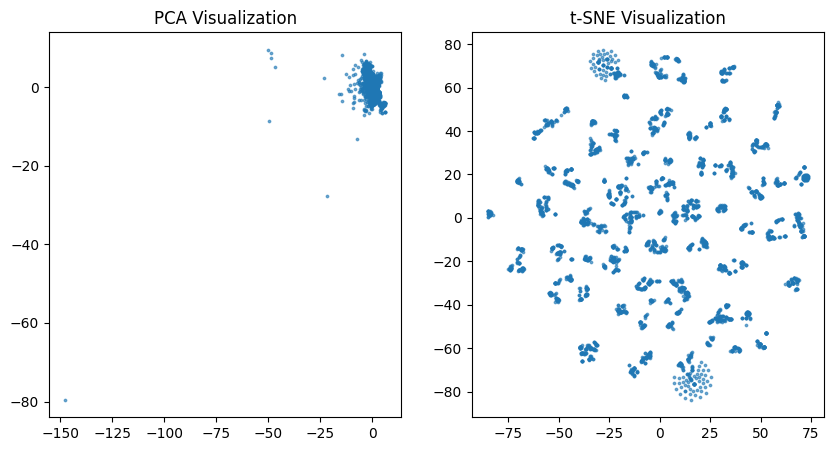

In [12]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_np)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(embeddings_np)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=3, alpha=0.6)
plt.title('PCA Visualization')
plt.subplot(1, 2, 2)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=3, alpha=0.6)
plt.title('t-SNE Visualization')
plt.show()

# Visualisation

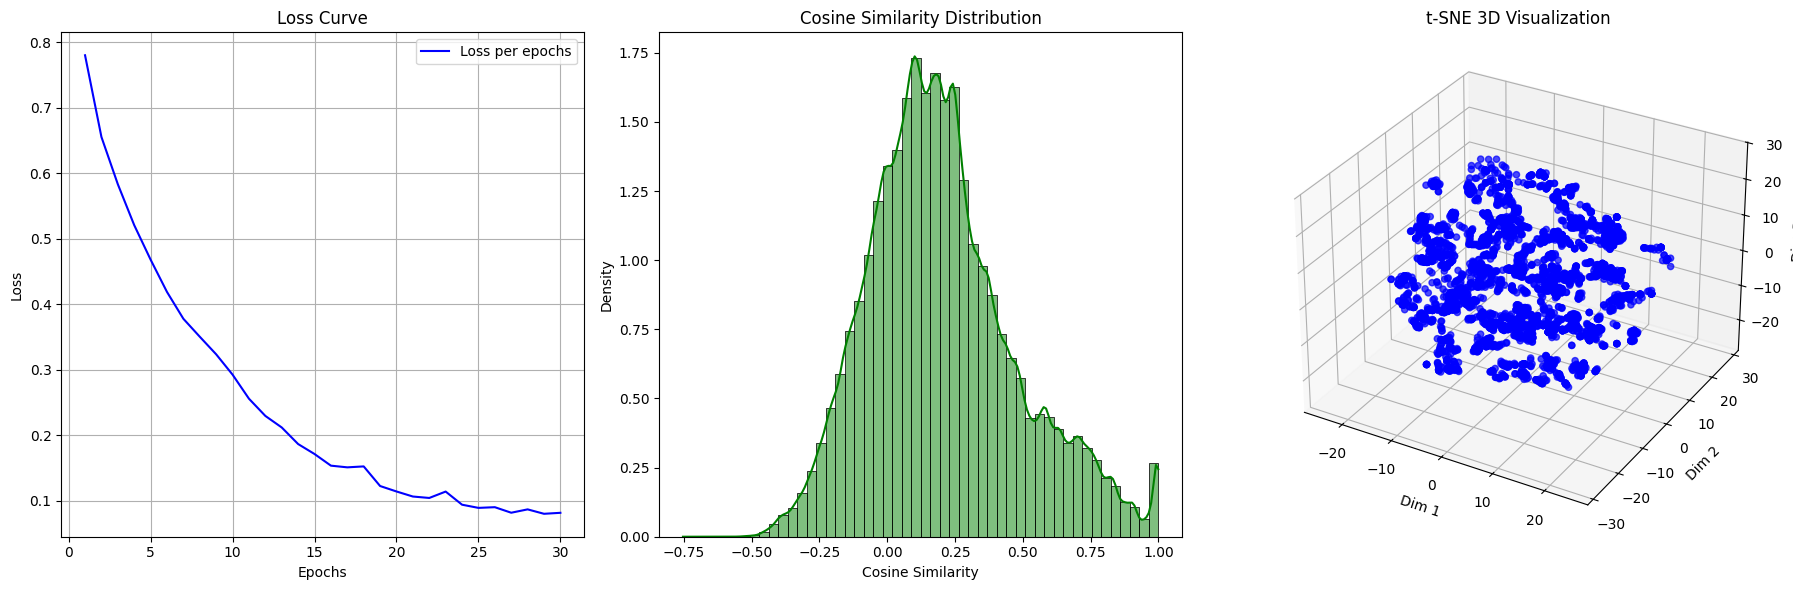

In [13]:
#Loss Curve
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(range(1, epochs + 1), loss_history, label='Loss per epochs', color='blue')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.grid(True)
ax1.legend()

#Cosine Similarity Histogram
ax2 = fig.add_subplot(1, 3, 2)
similarities = cosine_similarity(embeddings_np)
sim_scores = similarities[np.triu_indices_from(similarities, k=1)]
sns.histplot(sim_scores, bins=50, kde=True, color='green', stat='density', ax=ax2)
ax2.set_title('Cosine Similarity Distribution')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Density')

#t-SNE in 3D
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
tsne = TSNE(n_components=3, random_state=42)
embeddings_3d = tsne.fit_transform(embeddings_np)
ax3.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2], c='blue', alpha=0.7)
ax3.set_title('t-SNE 3D Visualization')
ax3.set_xlabel('Dim 1')
ax3.set_ylabel('Dim 2')
ax3.set_zlabel('Dim 3')
plt.tight_layout()
plt.show()

# Similarity

In [14]:
def recommend_from_sample_dict(sample_dict, full_embeddings, original_df, pipeline, model, top_n=5):
    sample_df = pd.DataFrame([sample_dict])
    transformed = pipeline.transform(sample_df)
    sample_tensor = torch.tensor(transformed, dtype=torch.float32)
    
    model.eval()
    with torch.no_grad():
        _, sample_embedding = model(sample_tensor)
        
    similarities = cosine_similarity(sample_embedding, full_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n]
    result_df = original_df.iloc[top_indices].copy()
    result_df['similarity_score'] = similarities[top_indices]
    result_df.reset_index(drop=True, inplace=True)
    return result_df

In [15]:
original_df.max().to_dict()

{'jobma_catcher_id': 10536,
 'company_size': 'More than 1000',
 'is_premium': 1,
 'subscription_status': 2,
 'jobma_catcher_status': 1,
 'sub_users': 40,
 'wallet_amount': 4995968.0,
 'is_unlimited': 1,
 'plan_type': 1,
 'subscription_sum': 1398501.6,
 'subscription_count': 116,
 'invitations': 50046,
 'pre_recorded_kit_counts': 292,
 'number_of_jobs_posted': 189,
 'pre_rec_interview_taken': 635,
 'days_since_login': '881-1200'}

In [16]:
sample_dict={'company_size': '101-500',
             'is_premium': 0,
             'subscription_status': 2,
             'jobma_catcher_status': 1,
             'sub_users': 0,
             'wallet_amount': 50.0,
             'is_unlimited': 1,
             'plan_type': 0,
             'subscription_count': 1,
             'invitations': 0,
             'pre_recorded_kit_counts': 2,
             'number_of_jobs_posted': 2,
             'pre_rec_interview_taken': 1,
             'subscription_sum': 208.2,
            'days_since_login':'881-1200' }

recommend_from_sample_dict(sample_dict, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,6145,101-500,0,1,1,0,60.0,1,0,56.3,1,0,0,0,0,881-1200,0.928894
1,7710,101-500,0,2,1,0,60.0,1,0,58.8,1,0,0,0,0,881-1200,0.928815
2,7855,101-500,0,2,1,0,60.0,1,0,23.5,1,0,0,0,0,881-1200,0.928226
3,7739,101-500,0,1,1,0,60.0,1,0,29.4,2,0,0,0,0,881-1200,0.927236
4,6656,101-500,0,2,1,0,60.0,1,0,117.6,1,0,0,0,0,881-1200,0.927103


In [17]:
sample_dict2 = { 'company_size': '101-500',
                 'is_premium': 0,
                 'subscription_status': 2,
                 'jobma_catcher_status': 1,
                 'sub_users': 0,
                 'wallet_amount': 60,
                 'is_unlimited': 0,
                 'plan_type': 0,
                 'subscription_count': 8,
                 'invitations': 25,
                 'pre_recorded_kit_counts': 3,
                 'number_of_jobs_posted': 5,
                 'pre_rec_interview_taken': 0,
                 'subscription_sum': 118.8,
                 'days_since_login': '0-324'}
recommend_from_sample_dict(sample_dict2, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,7500,101-500,0,1,1,1,3735.0,0,0,171.4,9,0,1,2,0,881-1200,0.792303
1,8135,101-500,0,1,1,0,60.0,0,0,71.4,7,0,0,0,0,881-1200,0.789864
2,7186,101-500,0,1,1,0,60.0,0,0,73.0,5,0,0,0,0,881-1200,0.763545
3,6916,101-500,0,2,1,1,60.0,0,0,64.8,5,0,0,0,0,881-1200,0.756620
4,7321,101-500,0,1,1,1,60.0,0,0,63.7,5,0,0,0,0,881-1200,0.756331


In [18]:
sample_dict3 = {'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 66,
                'is_unlimited': 1,
                'plan_type': 0,
                'subscription_count': 5,
                'invitations': 5,
                'pre_recorded_kit_counts':5 ,
                'number_of_jobs_posted': 5,
                'pre_rec_interview_taken': 10,
                'subscription_sum': 118.8,
                'days_since_login':'0-324'}

recommend_from_sample_dict(sample_dict3, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,8146,26-100,0,1,1,1,60.0,1,0,94.4,8,0,0,0,0,881-1200,0.850408
1,7933,26-100,0,1,1,1,60.0,1,0,126.5,5,0,0,0,0,881-1200,0.844066
2,6258,26-100,0,1,1,0,60.0,1,0,235.2,4,0,0,0,0,881-1200,0.839600
3,7635,26-100,0,2,1,0,60.0,1,0,23.6,2,0,0,0,0,881-1200,0.834420
4,8605,26-100,0,1,1,0,60.0,1,0,352.8,3,0,0,0,0,881-1200,0.830975


In [19]:
sample_dict4 = {'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 60.0,
                'is_unlimited': 1,
                'plan_type': 0,
                'subscription_count': 3,
                'invitations': 4,
                'pre_recorded_kit_counts': 1,
                'number_of_jobs_posted': 1,
                'pre_rec_interview_taken': 0,
                'subscription_sum': 118.5,
                'days_since_login': ''}
recommend_from_sample_dict(sample_dict4, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,7635,26-100,0,2,1,0,60.0,1,0,23.6,2,0,0,0,0,881-1200,0.816827
1,6119,26-100,0,2,1,0,60.0,1,0,56.3,1,0,0,0,0,881-1200,0.809082
2,6214,26-100,0,2,1,0,60.0,1,0,56.3,1,0,0,0,0,881-1200,0.809082
3,7688,26-100,0,2,1,0,60.0,1,0,11.8,1,0,0,0,0,881-1200,0.808143
4,5992,26-100,0,2,1,0,60.0,1,0,56.3,1,1,1,0,1,881-1200,0.805862


In [20]:
sample_dict5 = {'company_size': '1-25',
                'is_premium': 0,
                'subscription_status': 1,
                'jobma_catcher_status': 1,
                'sub_users': 1,
                'wallet_amount': 66.0,
                'is_unlimited': 1,
                'plan_type': 0,
                'subscription_count': 1,
                'invitations': 4,
                'pre_recorded_kit_counts': 2,
                'number_of_jobs_posted': 1,
                'pre_rec_interview_taken': 1,
                'subscription_sum': 176.5,
                'days_since_login': 418
               }

recommend_from_sample_dict(sample_dict5, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,7695,1-25,0,1,0,1,60.0,1,0,242.3,3,0,0,0,0,0-323,0.750131
1,7076,1-25,0,1,0,0,60.0,1,1,582.3,3,0,0,0,0,0-323,0.703156
2,4798,1-25,0,1,0,0,60.0,1,0,143.5,5,2,0,3,0,1351-1500,0.692326
3,7630,26-100,0,1,0,0,60.0,1,0,320.0,6,0,0,0,0,0-323,0.678376
4,5853,1-25,0,2,1,0,60.0,1,0,56.3,1,0,0,0,0,0-323,0.662450


In [21]:
original_df[original_df['jobma_catcher_id'] == 6227]

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login
2109,6227,500-1000,1,2,1,11,60.0,0,1,694.2,2,96,19,14,54,881-1200


In [22]:
sample_dict6 = {'company_size': '500-1000',
                'is_premium': 1,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 11,
                'wallet_amount': 60.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_sum': 694.2,
                'subscription_count': 2,
                'invitations': 96,
                'pre_recorded_kit_counts': 19,
                'number_of_jobs_posted': 14,
                'pre_rec_interview_taken': 54,
                'days_since_login': '881-1200',
               }
recommend_from_sample_dict(sample_dict6, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,6227,500-1000,1,2,1,11,60.0,0,1,694.2,2,96,19,14,54,881-1200,0.952511
1,6042,26-100,1,2,1,10,60.0,0,0,11.8,4,11,2,3,3,881-1200,0.786303
2,8334,500-1000,1,1,1,13,60.0,0,0,55.4,4,0,0,0,0,0-323,0.774623
3,8351,101-500,1,1,1,12,60.0,0,1,1110.6,4,0,0,0,0,0-323,0.773842
4,6017,500-1000,1,1,1,10,1860.0,0,0,56.7,11,15,6,9,5,441-510,0.767689


In [23]:
sample_dict7 = {'company_size': '101-500',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 1,
                'wallet_amount': 60.0,
                'is_unlimited': 0,
                'plan_type': 1,
                'subscription_sum': 347.1,
                'subscription_count': 1,
                'invitations':37,
                'pre_recorded_kit_counts': 4,
                'number_of_jobs_posted': 4,
                'pre_rec_interview_taken': 6,
                'days_since_login': '1351-1500',
               }
recommend_from_sample_dict(sample_dict7, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,5160,101-500,0,2,1,1,60.0,0,1,2.8,1,0,0,0,0,1351-1500,0.948233
1,5207,101-500,0,2,1,0,60.0,0,1,5.6,2,0,0,0,0,1351-1500,0.947833
2,5121,101-500,0,2,1,0,60.0,0,1,4.2,2,0,1,0,0,1351-1500,0.945995
3,4792,101-500,0,2,1,0,60.0,0,1,6.6,1,0,0,0,0,1351-1500,0.945992
4,4834,101-500,0,2,1,0,60.0,0,1,6.6,1,0,0,0,0,1351-1500,0.945992


In [24]:
original_df.max().to_dict()

{'jobma_catcher_id': 10536,
 'company_size': 'More than 1000',
 'is_premium': 1,
 'subscription_status': 2,
 'jobma_catcher_status': 1,
 'sub_users': 40,
 'wallet_amount': 4995968.0,
 'is_unlimited': 1,
 'plan_type': 1,
 'subscription_sum': 1398501.6,
 'subscription_count': 116,
 'invitations': 50046,
 'pre_recorded_kit_counts': 292,
 'number_of_jobs_posted': 189,
 'pre_rec_interview_taken': 635,
 'days_since_login': '881-1200'}

In [25]:
sample2={'company_size': 'More than 1000',
         'is_premium': 1,
         'subscription_status': 2,
         'jobma_catcher_status': 1,
         'sub_users': 40,
         'wallet_amount': 4995968.0,
         'is_unlimited': 1,
         'plan_type': 1,
         'subscription_sum': 1398501.6,
         'subscription_count': 116,
         'invitations': 50046,
         'pre_recorded_kit_counts': 292,
         'number_of_jobs_posted': 189,
         'pre_rec_interview_taken': 635,
         'days_since_login': '881-1200'}
recommend_from_sample_dict(sample2, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,10063,1-25,0,1,1,1,24.0,0,0,0.0,1,50046,6,9,21,381-440,0.959494
1,7099,1-25,0,1,1,1,4995968.0,0,1,1175.2,5,27,4,2,25,441-510,0.552888
2,8554,More than 1000,1,1,1,1,500000.0,1,0,237.6,17,12,4,8,11,324-380,0.549216
3,3678,26-100,1,2,1,13,60.0,0,1,208452.3,33,485,27,92,215,1351-1500,0.536593
4,6185,More than 1000,1,1,1,1,60.0,0,1,2637.6,10,217,31,51,124,881-1200,0.533881


In [26]:
original_df[original_df['jobma_catcher_id'] == 2956]

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login
21,2956,101-500,0,2,1,0,60.0,0,1,138.8,1,0,0,1,0,1641-5000


In [49]:
original_df.iloc[1].to_dict()

{'jobma_catcher_id': 2935,
 'company_size': '26-100',
 'is_premium': 0,
 'subscription_status': 2,
 'jobma_catcher_status': 1,
 'sub_users': 0,
 'wallet_amount': 60.0,
 'is_unlimited': 0,
 'plan_type': 1,
 'subscription_sum': 0.6,
 'subscription_count': 1,
 'invitations': 0,
 'pre_recorded_kit_counts': 0,
 'number_of_jobs_posted': 0,
 'pre_rec_interview_taken': 0,
 'days_since_login': '441-510'}

In [50]:
sample_0=original_df.iloc[1].to_dict()

In [51]:
recommend_from_sample_dict(sample_0, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login,similarity_score
0,2935,26-100,0,2,1,0,60.0,0,1,0.6,1,0,0,0,0,441-510,0.972819
1,2938,26-100,0,1,1,0,50.0,0,1,178.8,3,0,0,1,0,441-510,0.959320
2,8434,26-100,0,1,1,0,1860.0,0,0,23.0,2,0,0,0,0,441-510,0.951762
3,7999,26-100,0,1,1,1,11860.0,0,0,38.8,2,0,0,0,0,441-510,0.947857
4,10152,26-100,0,1,1,0,150.0,0,0,1.8,1,0,1,1,0,441-510,0.945970


# Saving pipeline and model

In [30]:
# model

In [31]:
embeddings.shape

torch.Size([4466, 32])

In [32]:
embeddings_np.shape

(4466, 32)

In [ ]:
import torch
import numpy as np

In [ ]:
joblib.dump(pipeline, 'preprocessing_pipeline.pkl')

In [ ]:
torch.save(model.state_dict(), 'autoencoder_model.pt')
np.save('embeddings.npy', embeddings_np)
original_df.to_csv('original_data.csv', index=False)